In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import warnings 
warnings.filterwarnings("ignore")

data = pd.read_csv('/kaggle/input/newdata/ProductionDataAll - Copy.csv')

In [2]:
# impute missing values
data['Temperature'] = data['Temperature'].interpolate()

In [3]:
# convert date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [4]:
# get unique values
countries = data['Country'].unique()

In [5]:
# create a list to store all the processed country data
all_country_data = []

for country in countries:
    country_data = data[data['Country'] == country].copy() # Create a copy to avoid SettingWithCopyWarning
    stl = STL(country_data['Temperature'], period=12)
    result = stl.fit()
    country_data['trend'] = result.trend
    country_data['seasonal'] = result.seasonal
    country_data['residual'] = result.resid
    country_data['month'] = country_data['Date'].dt.month  # Add month column
    country_data['trend_lag1'] = country_data['trend'].shift(1)  # Add lagged trend column
    country_data.dropna(inplace=True)
    all_country_data.append(country_data)

In [6]:
# Concatenate all the processed country data back into a single DataFrame
stl_data = pd.concat(all_country_data)

In [7]:
#split the data into train and test
train = stl_data[stl_data['Date'].dt.year <= 2019]
test = stl_data[stl_data['Date'].dt.year > 2019]

In [8]:
# create a linear regression model
X_train = train[['trend', 'seasonal', 'month']]
y_train = train['Temperature']
X_test = test[['trend', 'seasonal', 'month']]
y_test = test['Temperature']

In [9]:
# train the model
model_test = LinearRegression()
model_test.fit(X_train, y_train)

LinearRegression()

In [10]:
# evaluate the model
y_pred = model_test.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
# Calculate RMSE manually or update scikit-learn
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAE: {mae}, RMSE: {rmse}, MAPE: {mape}',)

MAE: 0.43688622672256766, RMSE: 0.6449453093992714, MAPE: 0.02247315619904974


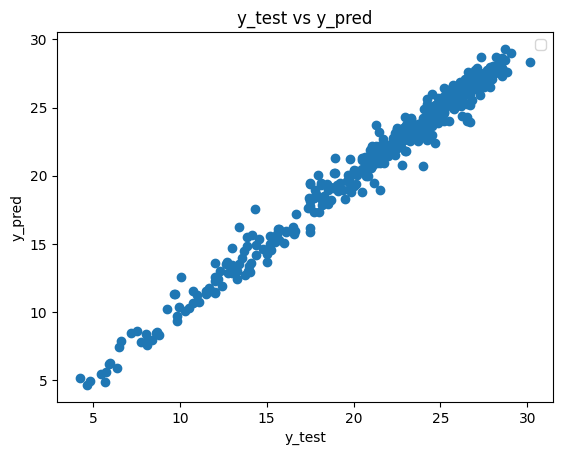

In [11]:
# Plot y_test vs  y_pred
plt.scatter(y_test, y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test vs y_pred')
plt.legend()
plt.show()

In [12]:
X = stl_data[['trend', 'seasonal', 'month']]
y = stl_data['Temperature']
# train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [13]:
# predict future values for the next 5 years for each country
future_predictions = []
for country in countries:
    # Get the last 5 years' data for the country
    last_five_years_data = stl_data[
        (stl_data['Country'] == country) & (stl_data['Date'].dt.year >= 2019) & (stl_data['Date'].dt.year <= 2024)
    ]
    
    # predict future values for the next 5 years
    future_dates = pd.date_range(start='2025-01-01', periods=60, freq='M')
    future_df = pd.DataFrame({'Date': future_dates})
    future_df['month'] = future_df['Date'].dt.month

    # Dynamic trend and seasonal using the average of the last 5 years
    future_df['trend'] = np.tile(last_five_years_data.groupby('month')['trend'].mean().values, 5)
    future_df['seasonal'] = np.tile(last_five_years_data.groupby('month')['seasonal'].mean().values, 5)

    # predict future values for the next 5 years
    future_df['Temperature'] = model.predict(future_df[['trend', 'seasonal', 'month']])
    future_df['Country'] = country

    future_predictions.append(future_df)
# Concatenate the list of DataFrames into a single DataFrame
required_dataset = pd.concat(future_predictions)[['Country', 'Date', 'Temperature']]
# Convert 'Date' to the first day of the month
required_dataset['Date'] = required_dataset['Date'].dt.to_period('M').dt.to_timestamp()

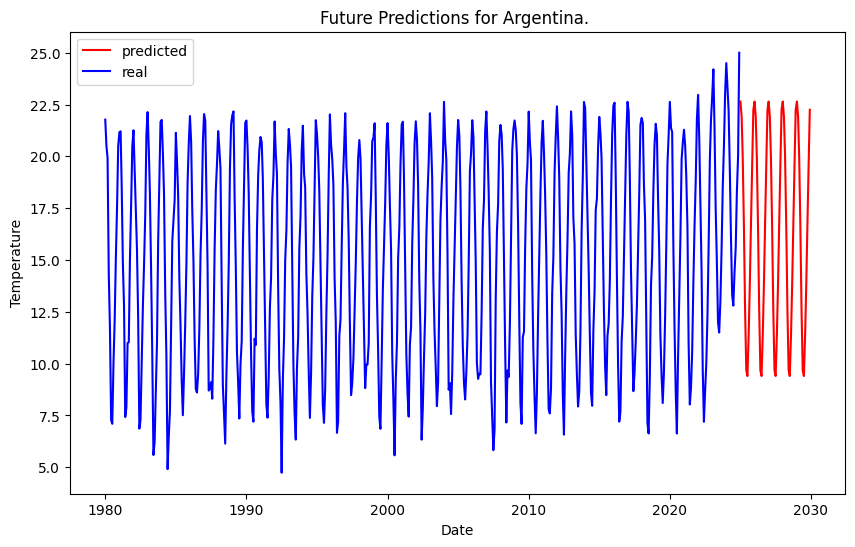

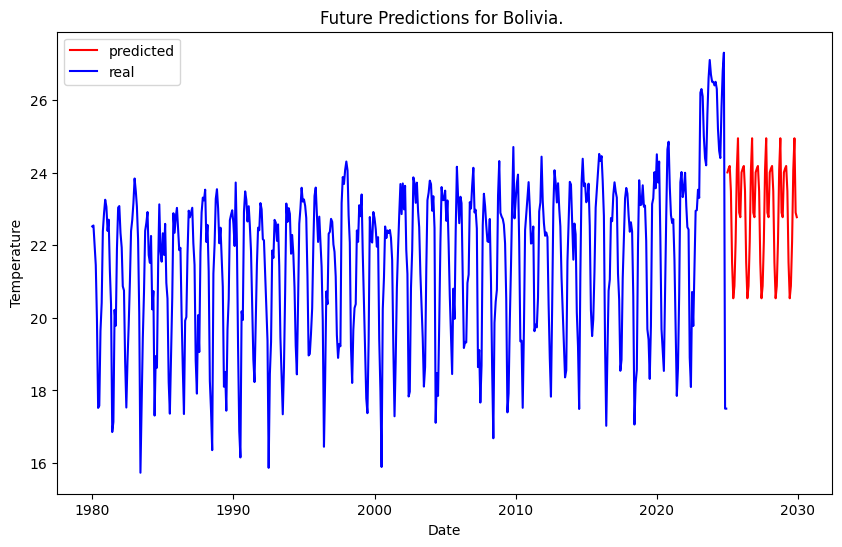

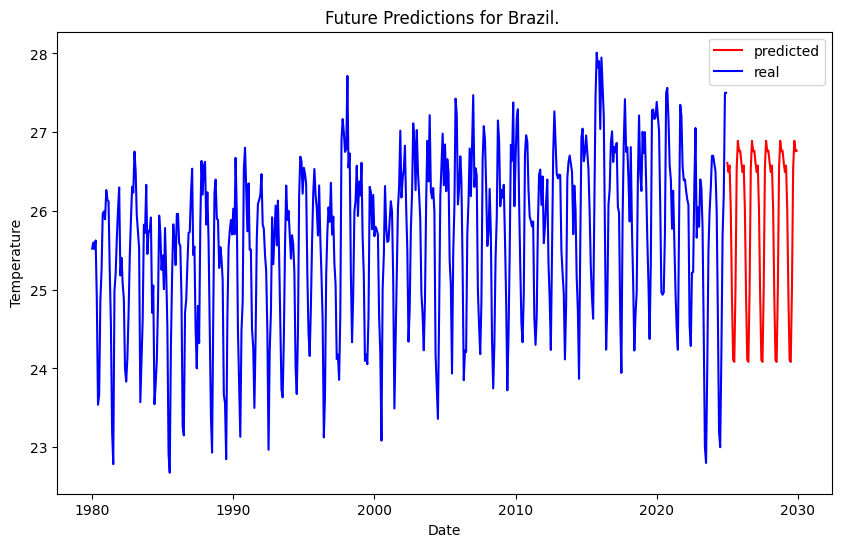

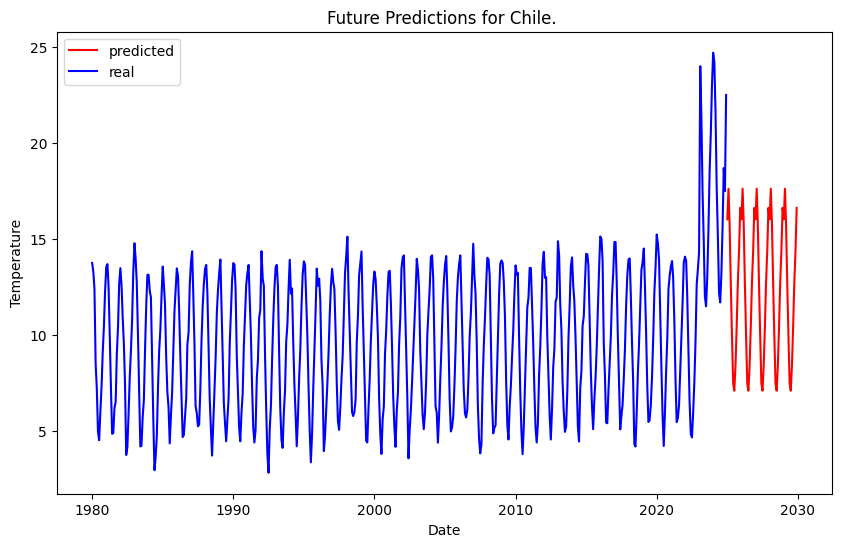

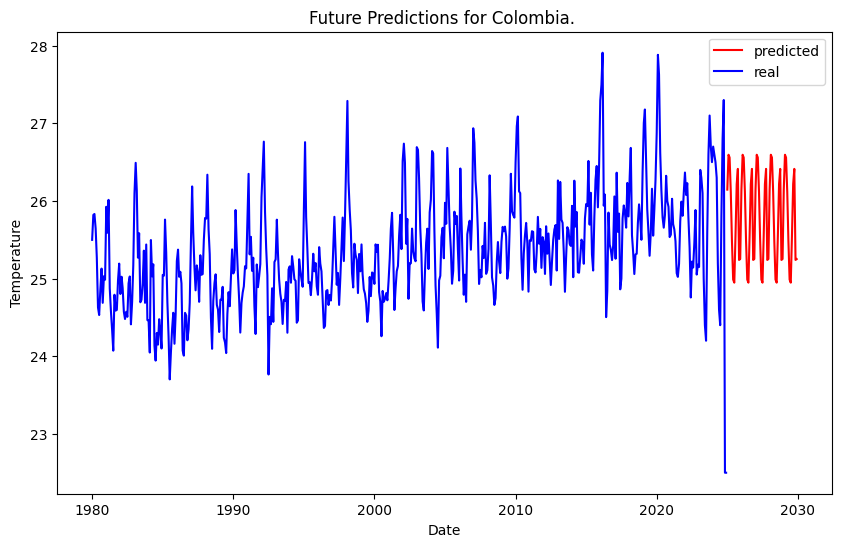

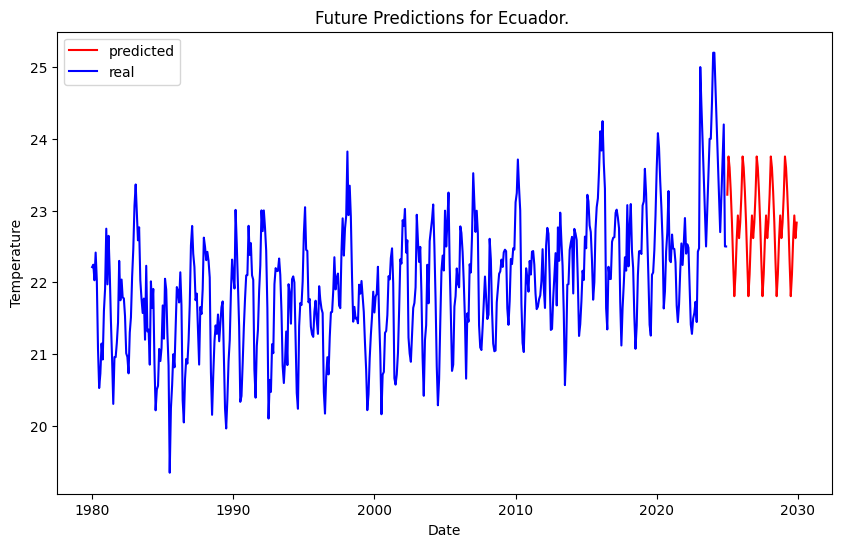

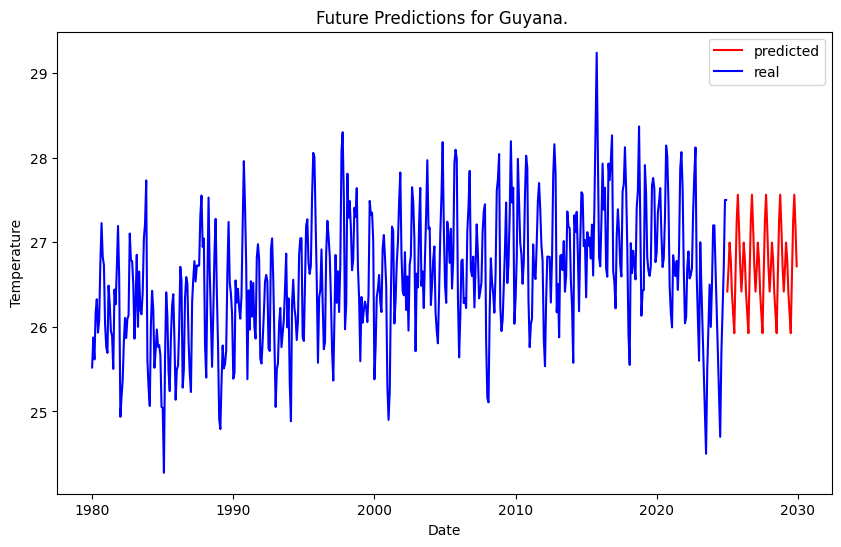

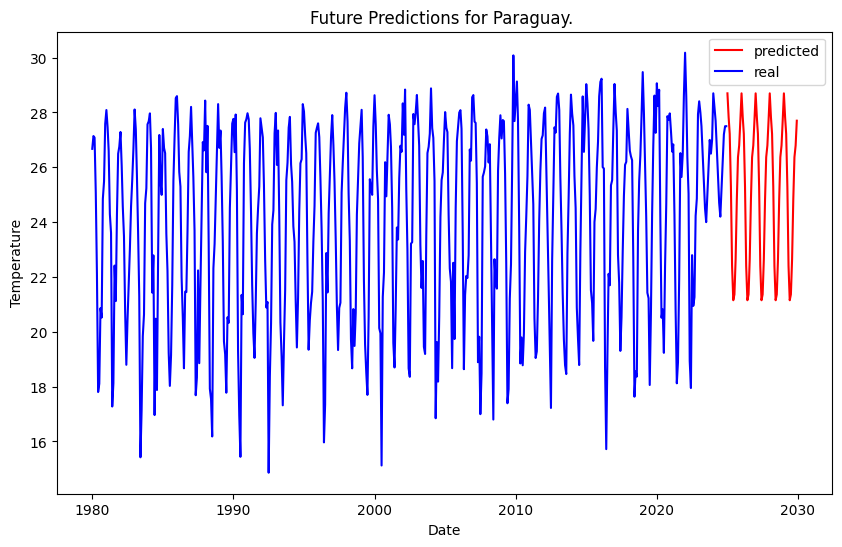

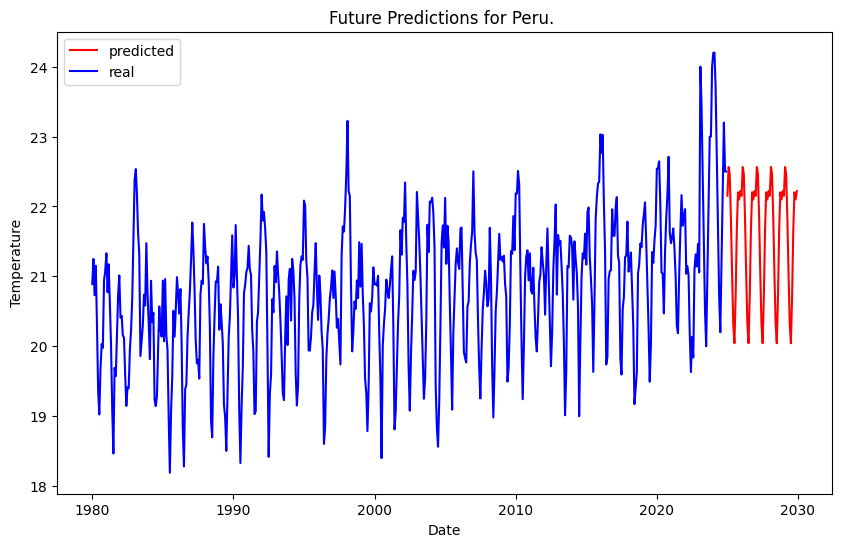

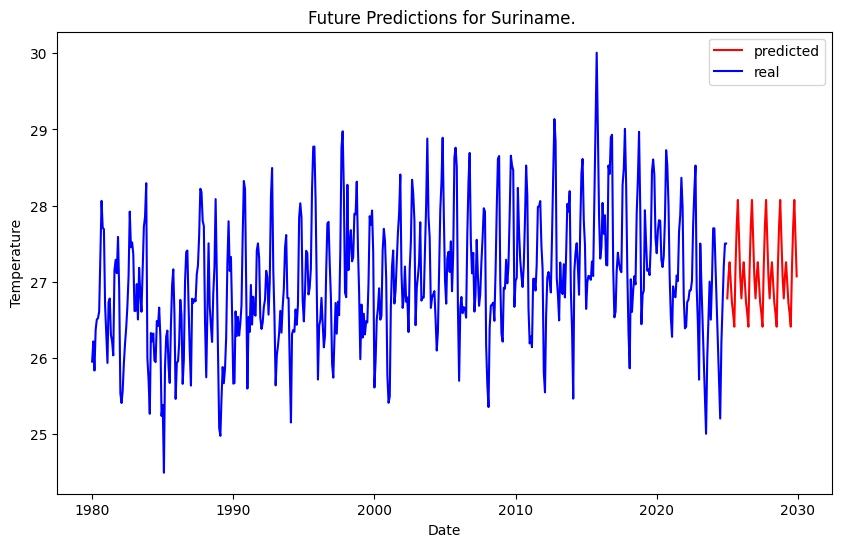

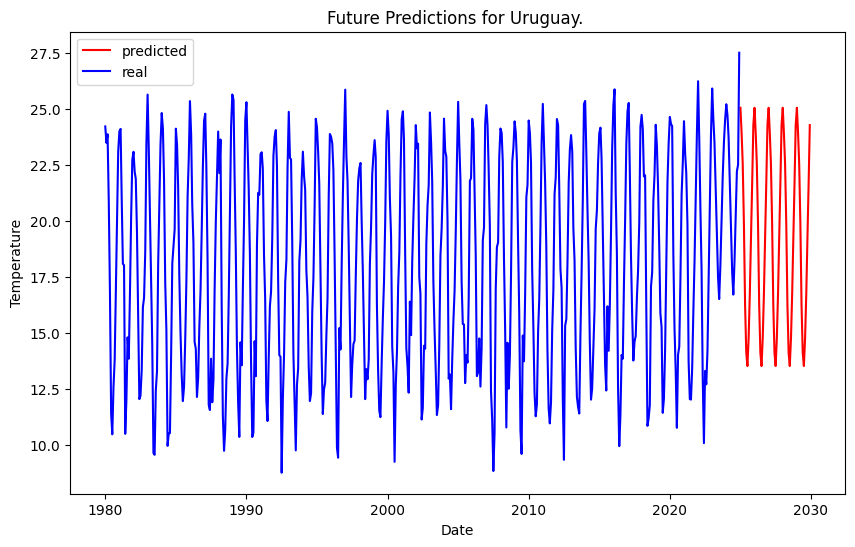

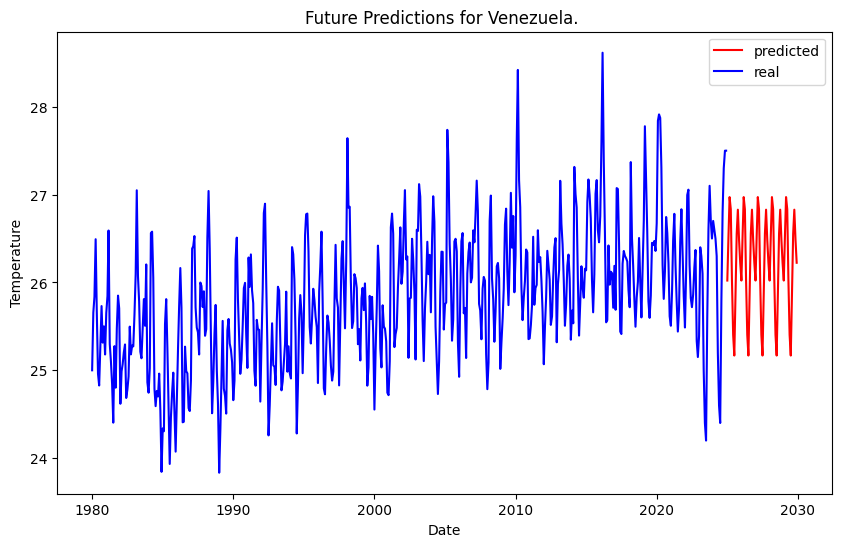

In [14]:
# plot the future predictions for each country
for country in countries:
    country_data = required_dataset[required_dataset['Country'] == country]
    real_data = data[data['Country'] == country]
    plt.figure(figsize=(10, 6))
    plt.xlabel('Date')
    plt.ylabel('Temperature')
    plt.title(f'Future Predictions for {country}. ')
    plt.plot(country_data['Date'], country_data['Temperature'], label='predicted', color = 'r')
    plt.plot(real_data['Date'], real_data['Temperature'], label='real', color = 'b')
    plt.legend()
    plt.show()

In [15]:
# save the future predictions to a csv file
required_dataset.to_csv('STL_temperature_forecasts.csv')